# Chapter 4: Empirical Results & Performance Analysis
## Research Question 1: Predictive Performance Across Model Paradigms

This notebook aggregates evaluation metrics across all model paradigms (**Encoder Fine-Tuning**, **Local QLoRA**, **Local Prompted LLMs**, and **Cloud API LLMs**) across four benchmark datasets: `20_newsgroups`, `ag_news`, `banking77`, and `emotion`.


In [1]:
import sys
import os
import pandas as pd
from IPython.display import display, Image

# Import analysis helper utilities
sys.path.append('.')
from analysis_utils import (
    load_all_results, 
    create_master_performance_table,
    plot_figure_4_1_grouped_bar,
    plot_figure_4_2_training_convergence,
    plot_figure_4_3_parse_reliability
)

# Load data from structured results directory
RESULTS_DIR = "../results_by_model"
df = load_all_results(RESULTS_DIR)
print(f"Successfully loaded {len(df)} experiment evaluations.")


Saved aggregated performance results to CSV: /home/vvet/Documents/Dissertation/Experiments/results/all_results.csv
Successfully loaded 67 experiment evaluations.


### 1.1 Master Classification Benchmark Table
**Purpose**: Comprehensive comparison of all models across all datasets and paradigms.

- **Columns**: 
  - **Paradigm**: Encoder Fine-Tuning / Local QLoRA / Local Prompted LLM / Cloud API LLM
  - **Model**: RoBERTa-base, BERT-base, DistilBERT-base, Llama-3.1-8B (QLoRA, Zero-Shot, Few-Shot), GPT-5.6-luna (Zero-Shot, Few-Shot)
  - **Datasets (Head Columns)**: `20_newsgroups`, `ag_news`, `banking77`, `emotion`
  - **Sub-Columns (per dataset)**: `Accuracy` and `Macro F1`
- **Metric Aggregation**: Averaged across random seeds ($42, 43, 44$).


In [2]:
print("=== TABLE 4.1: MASTER CLASSIFICATION PERFORMANCE BENCHMARK ===")
table_master_perf = create_master_performance_table(df)
display(table_master_perf)


=== TABLE 4.1: MASTER CLASSIFICATION PERFORMANCE BENCHMARK ===


Dataset                                      20_newsgroups           ag_news  \
Metric                                            Accuracy Macro F1 Accuracy   
Paradigm            Model                                                      
Encoder Fine-Tuning BERT-base                       0.7232   0.7029   0.9457   
                    DistilBERT-base                 0.7099   0.6856   0.9442   
                    RoBERTa-base                    0.7312   0.7125   0.9499   
Local QLoRA         Llama-3.1-8B (QLoRA)            0.8008   0.7901   0.9528   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)         0.2463   0.2477   0.7918   
                    Llama-3.1-8B (Zero-Shot)        0.4006   0.3587   0.7478   
Cloud API LLM       GPT-5.6-luna (Few-Shot)         0.7770   0.7675   0.8667   
                    GPT-5.6-luna (Zero-Shot)        0.7615   0.7495   0.8657   

Dataset                                               banking77           \
Metric                                       Macro F1  Accuracy Macro F1   
Paradigm            Model                                                  
Encoder Fine-Tuning BERT-base                  0.9458    0.8540   0.8395   
                    DistilBERT-base            0.9442    0.8287   0.8181   
                    RoBERTa-base               0.9499    0.9122   0.9110   
Local QLoRA         Llama-3.1-8B (QLoRA)       0.9528    0.9441   0.9441   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.7794    0.6482   0.6420   
                    Llama-3.1-8B (Zero-Shot)   0.7415    0.4506   0.4287   
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.8649    0.8846   0.8830   
                    GPT-5.6-luna (Zero-Shot)   0.8643    0.8521   0.8442   

Dataset                                       emotion           
Metric                                       Accuracy Macro F1  
Paradigm            Model                                       
Encoder Fine-Tuning BERT-base                  0.9277   0.8797  
                    DistilBERT-base            0.9260   0.8791  
                    RoBERTa-base               0.9308   0.8916  
Local QLoRA         Llama-3.1-8B (QLoRA)       0.9340   0.8920  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.4560   0.4039  
                    Llama-3.1-8B (Zero-Shot)   0.5315   0.4500  
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.6130   0.5528  
                    GPT-5.6-luna (Zero-Shot)   0.6520   0.5888

- LLama had the highest performance accross all datasets
- Both LLama FS and ZS had the lowest performance
- Encoders were competitive, higest performing was ROberta, which ouprformade cloud API on all datasets.
- Cloud API pefroemce consideratably better than llama fs and zr  but drastic low on emotion dataset 
- Similar pattern in Macro f1 as well
- Unfinetuned performs terrible compared to finetuned

### 1.2 Figure 4.1: Grouped Bar Chart — Macro F1 Across Models & Datasets
- **Type**: Grouped Bar Chart with Error Bars (std dev across seeds).
- **X-Axis**: Datasets (`20_newsgroups`, `ag_news`, `banking77`, `emotion`).
- **Y-Axis**: Macro F1 Score ($0.0 - 1.0$).
- **Color Grouping**: Paradigm (Encoders vs. Local LLMs vs. Cloud API LLMs).
- **Key Insight**: Highlights whether small fine-tuned models outperform zero/few-shot LLMs on domain-specific classification tasks.


Saved Figure 4.1 to: ../results/plots/fig4_1_macro_f1_by_paradigm.png


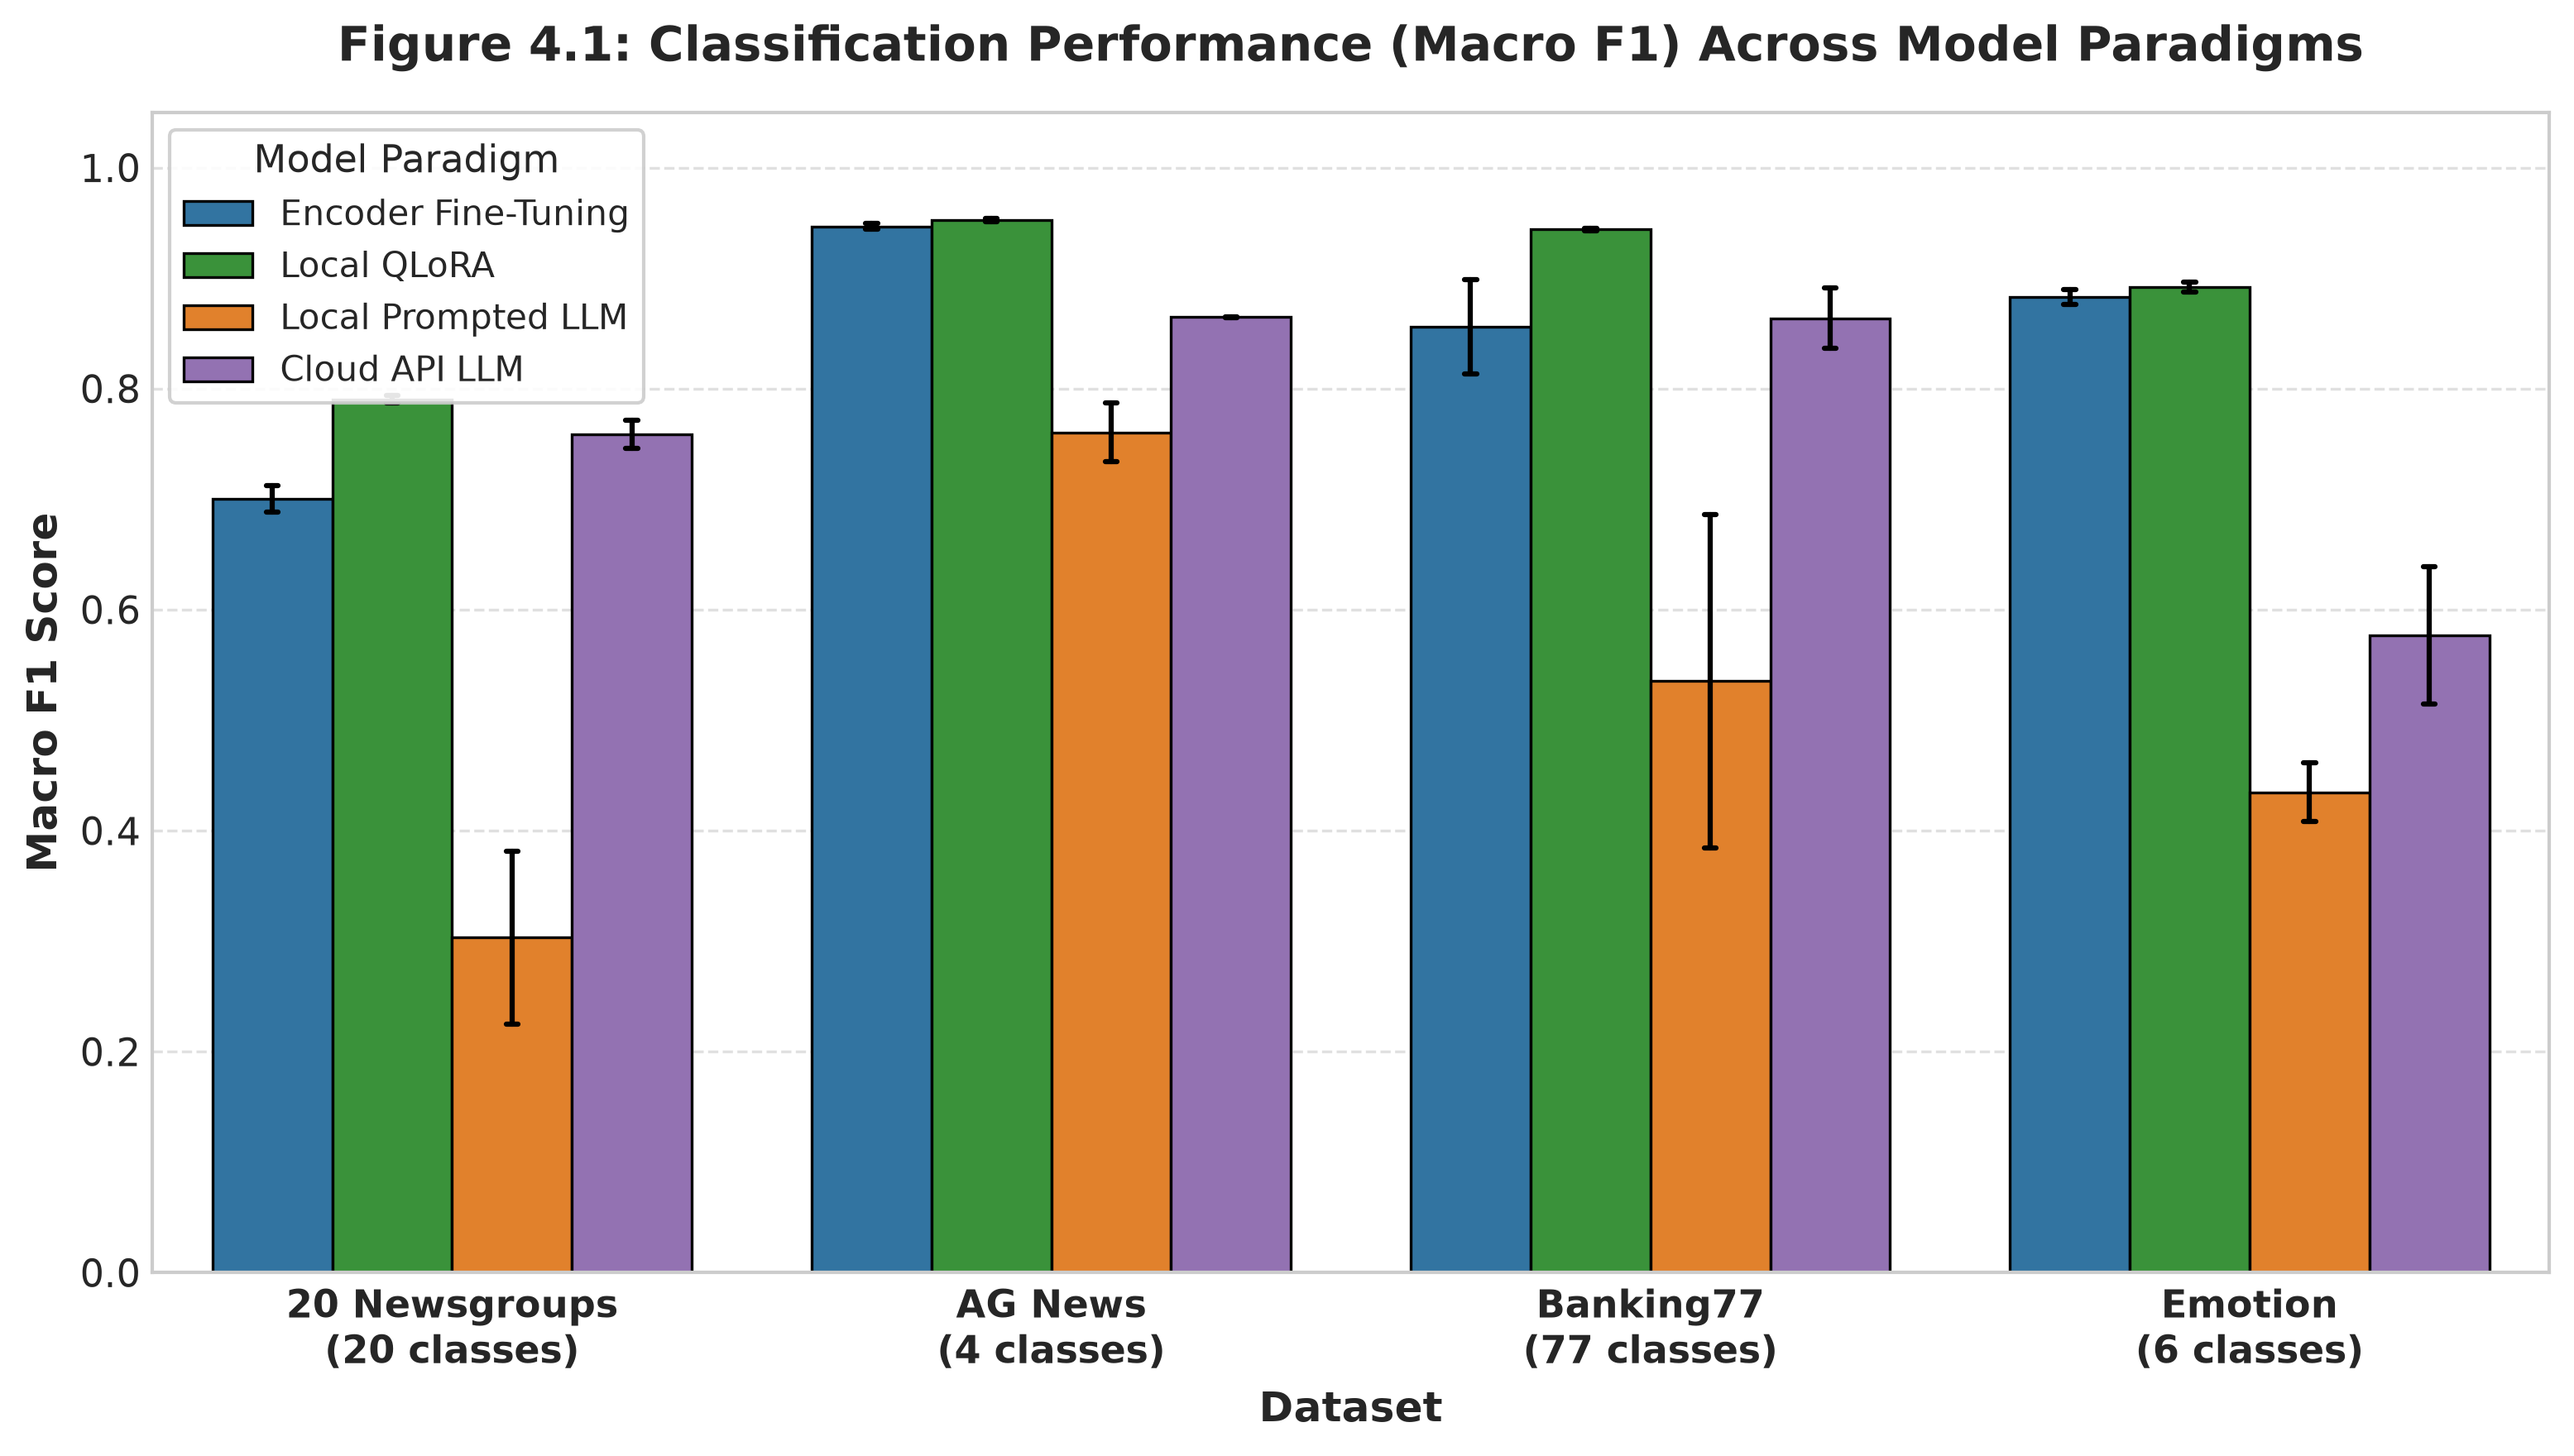

In [3]:
fig1_path = "../results/plots/fig4_1_macro_f1_by_paradigm.png"
plot_figure_4_1_grouped_bar(df, output_path=fig1_path)
display(Image(filename=fig1_path))


- Inline with the diagram, local unfinetuned performed the worst on all counts 
- Local QLora was compeitive as well
- error bars for local and endocders were almost negligible, but error bars for local prompted llm showed variance especially in Banking77 


### 1.3 Figure 4.2: Fine-Tuning Convergence Trajectory Across Epochs
- **Type**: Multi-line Chart with Shaded Error Bands (std dev across seeds).
- **X-Axis**: Training Epoch ($1, 2, 3$).
- **Y-Axis**: Validation Macro F1 Score.
- **Lines**: RoBERTa-base vs. BERT-base vs. Llama-3.1-8B (QLoRA).
- **Key Insight**: Demonstrates the speed of convergence, diminishing returns after Epoch 2, and sample efficiency across model scales.


Saved Figure 4.2 to: ../results/plots/fig4_2_training_convergence.png


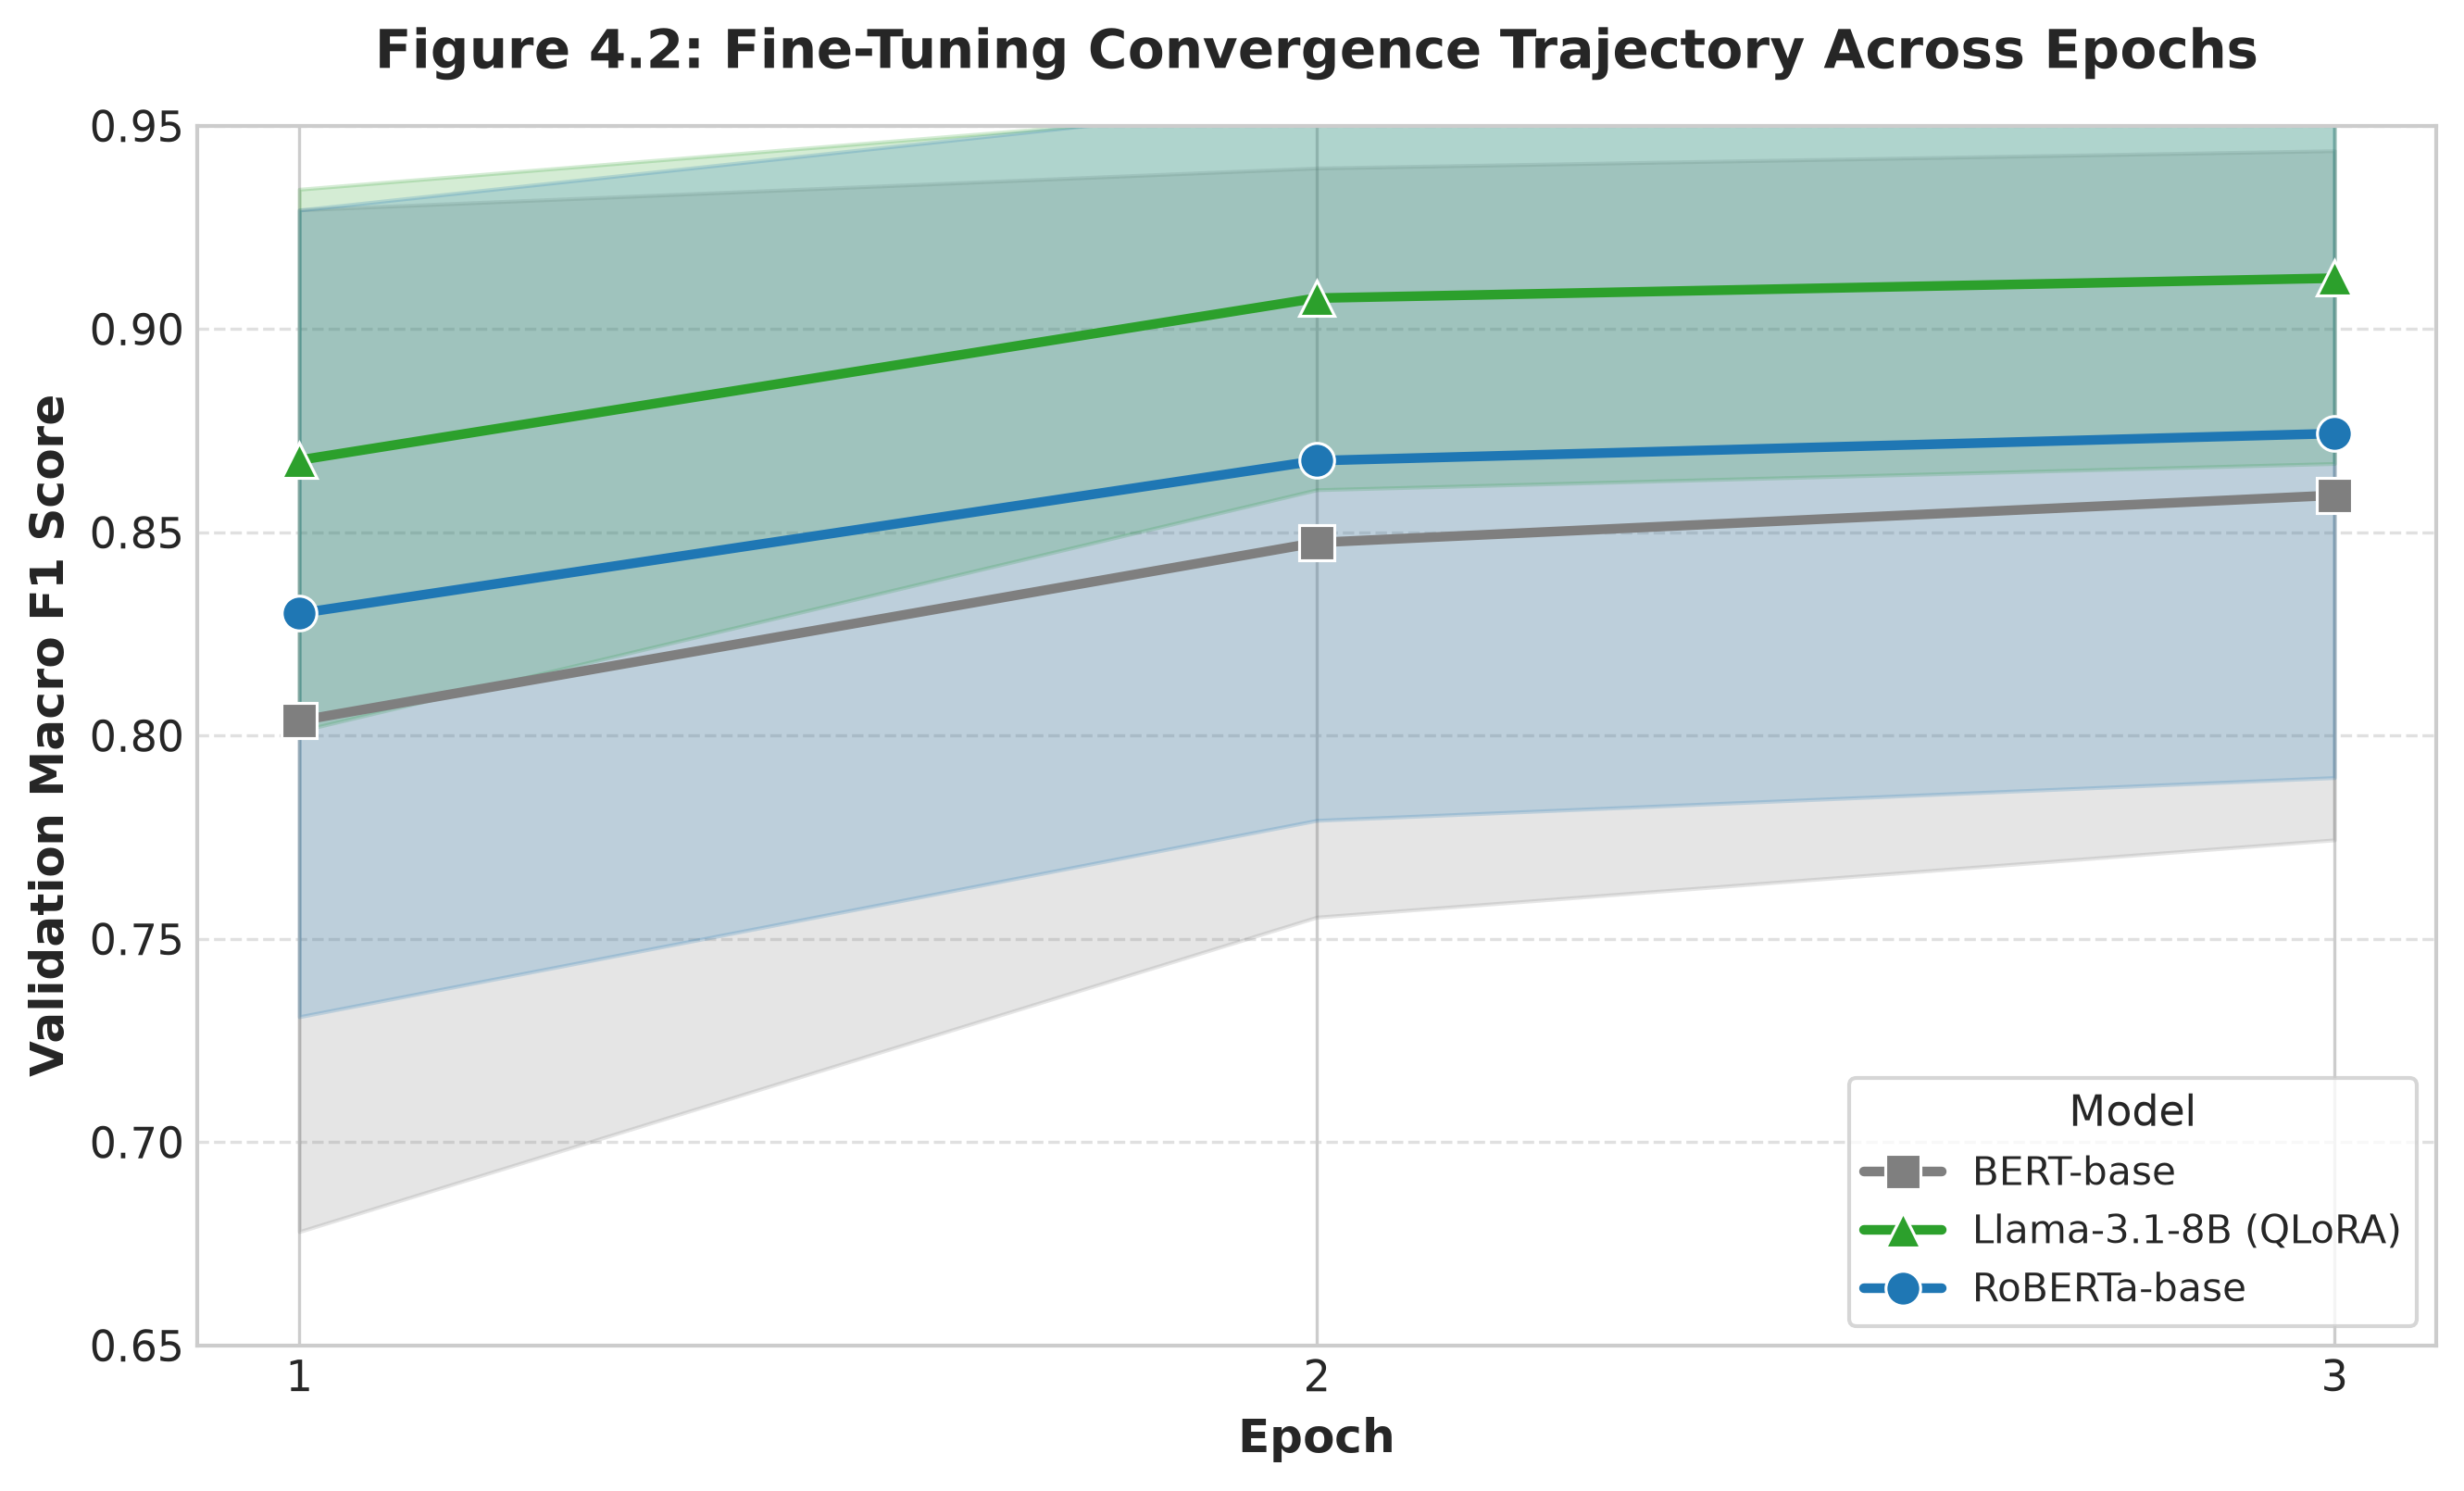

In [4]:
fig2_path = "../results/plots/fig4_2_training_convergence.png"
plot_figure_4_2_training_convergence(df, output_path=fig2_path)
display(Image(filename=fig2_path))


### 1.4 Figure 4.3: Prompted LLM Output Parse Reliability
- **Type**: 100% Stacked Bar Chart.
- **X-Axis**: Prompted Models (Local Prompted LLMs & Cloud API LLMs).
- **Y-Axis**: Percentage ($0 - 100\%$).
- **Segments**: Primary Parse (structured JSON), Fallback Parse (regex extraction), Failed Parse (unusable response).
- **Key Insight**: Evaluates operational reliability and structured compliance of generative text models for deterministic classification pipelines.


Saved Figure 4.3 to: ../results/plots/fig4_3_parse_reliability.png


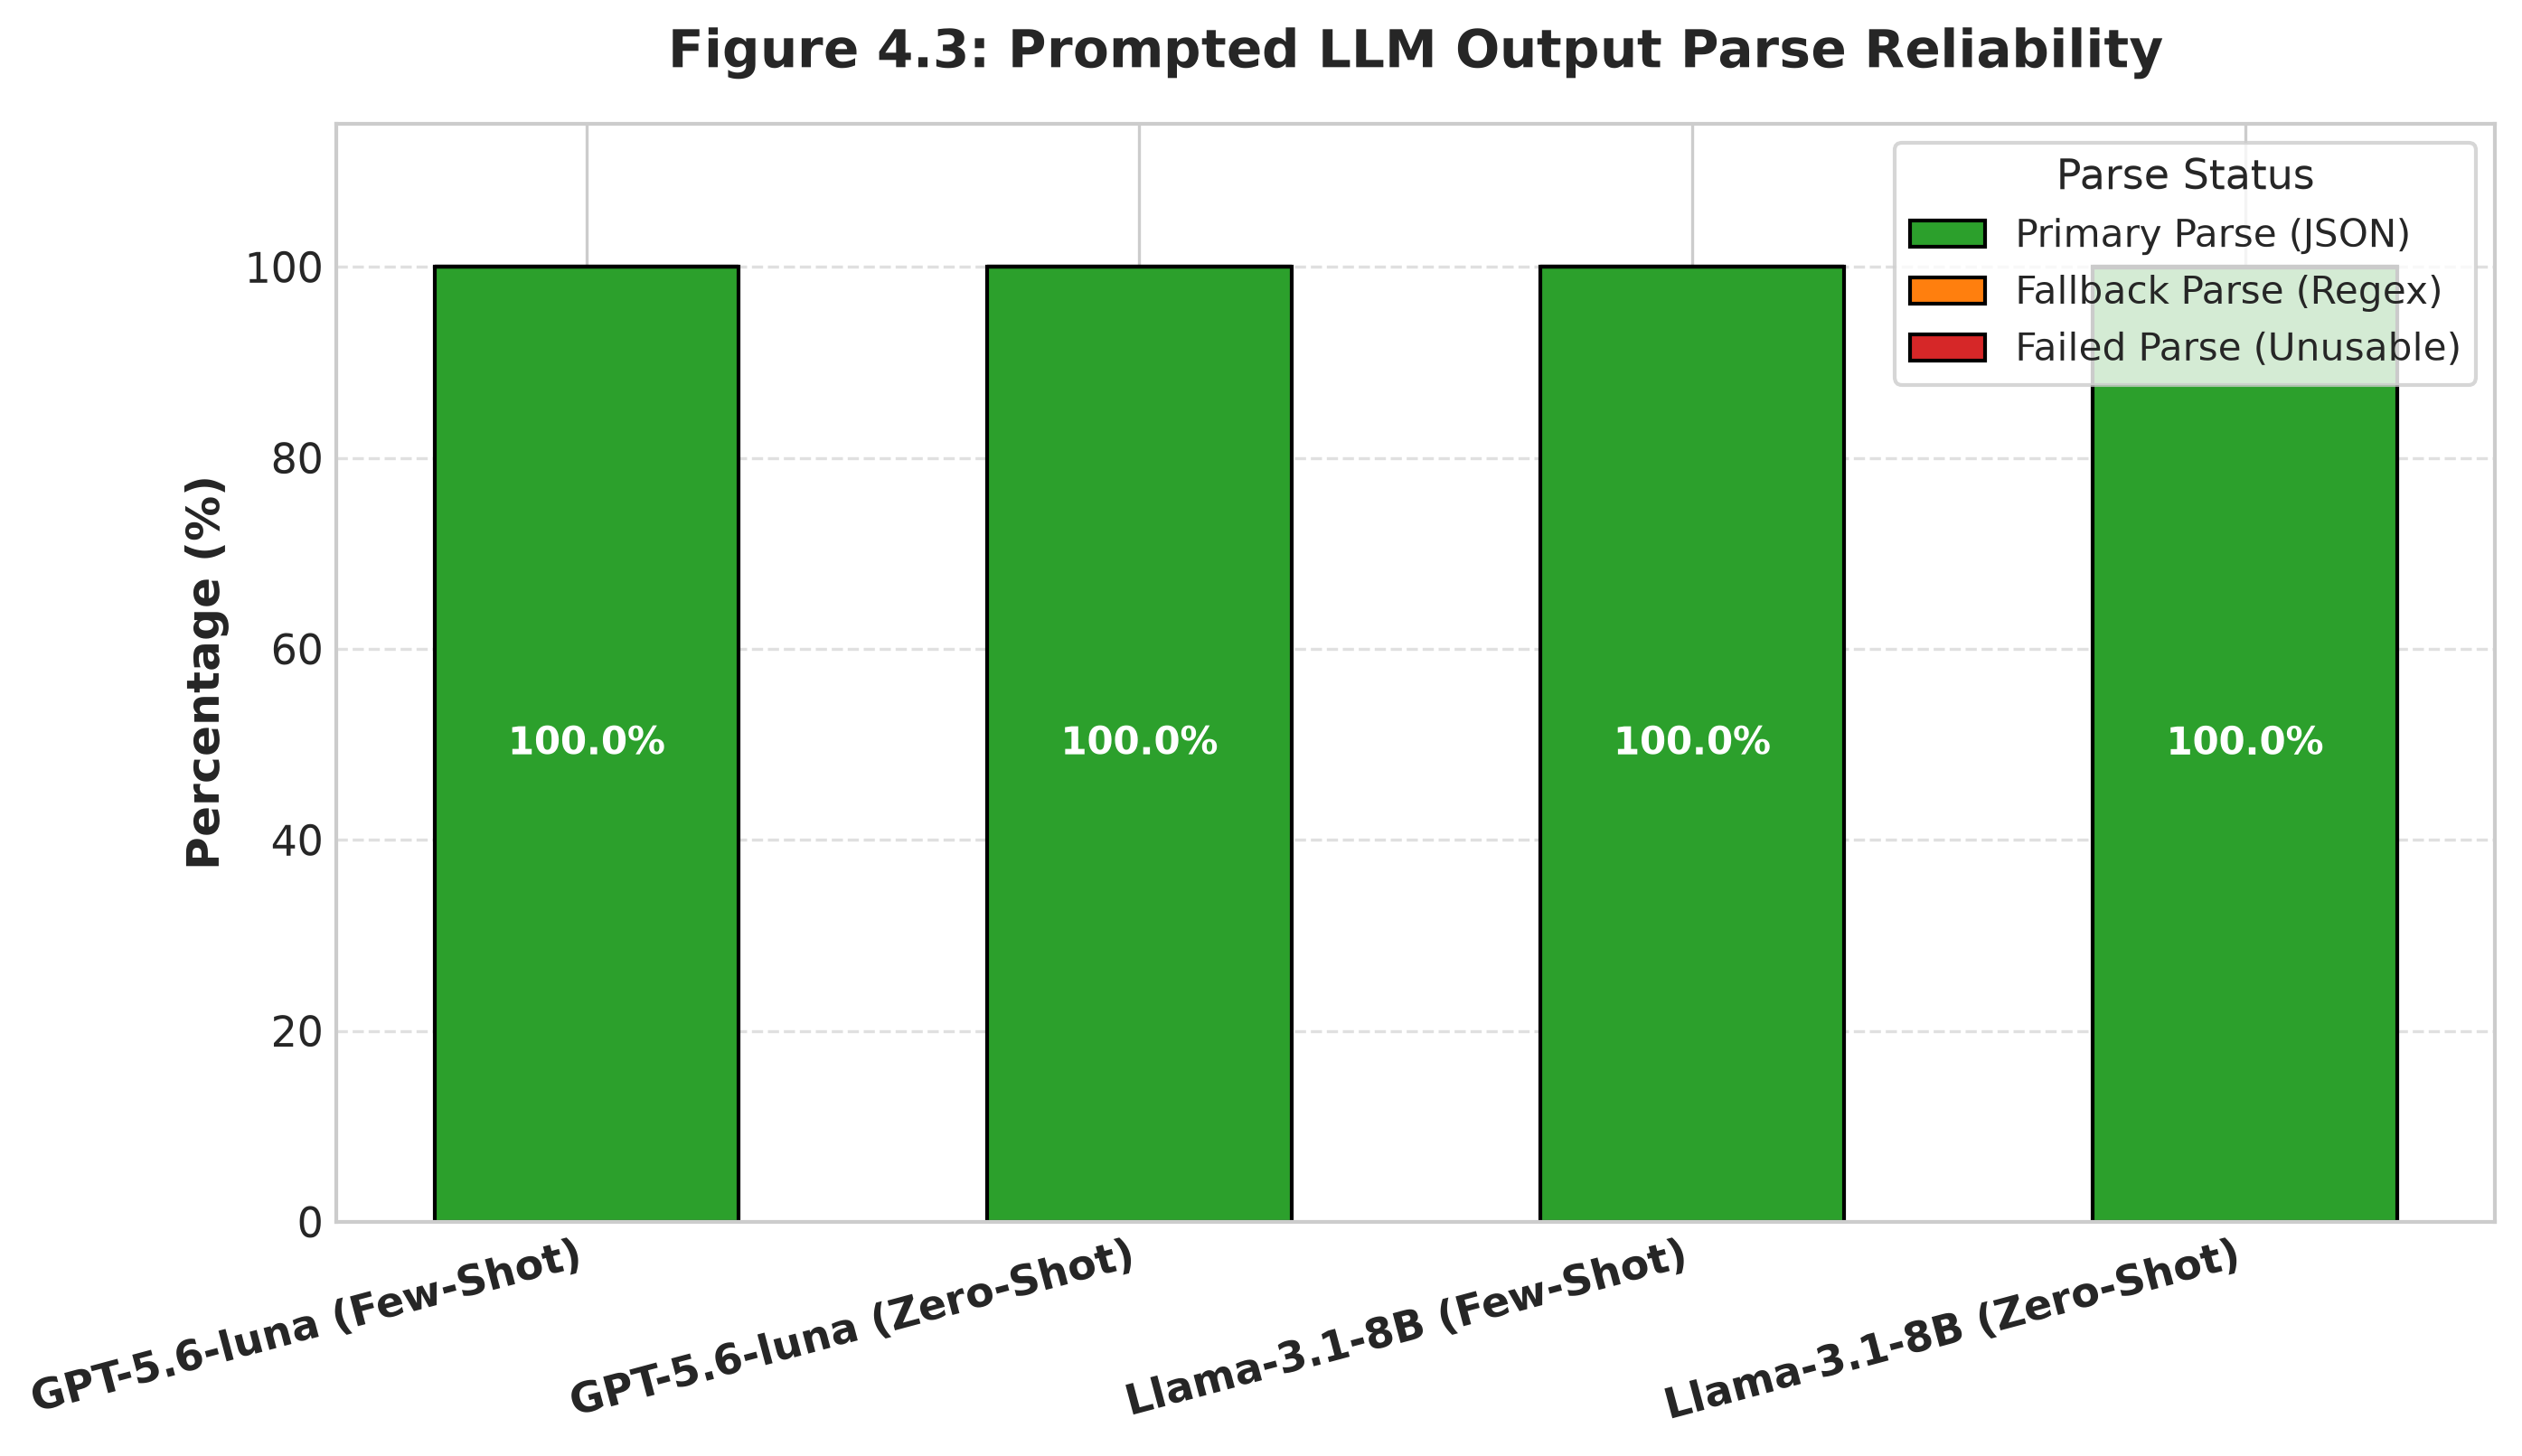

In [5]:
fig3_path = "../results/plots/fig4_3_parse_reliability.png"
plot_figure_4_3_parse_reliability(df, output_path=fig3_path)
display(Image(filename=fig3_path))


- All models that went through FS and ZR had zero percent failure rate. 